# Predicting NBA Wins Using Team Statistics

**Author:** Shaheer Malik  
**Team:** Individual  

**Problem:**  
This project investigates how well multiple NBA team statistics can predict how many games a team wins in a season.

**Data:**  
The dataset contains NBA team statistics from multiple seasons, including games played, wins, points, rebounds, assists, turnovers, steals, and blocks.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


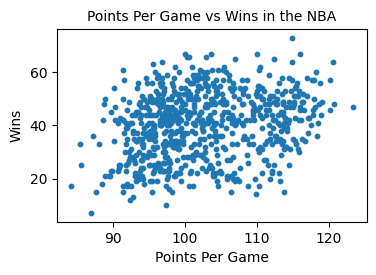

In [ ]:
# This block loads the dataset, creates points per game, and shows the basic relationship with wins

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (make sure file is uploaded or Drive is mounted)
NBA_data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/nba_team_stats_00_to_23.csv')

# Create points per game
NBA_data["ppg"] = NBA_data["points"] / NBA_data["games_played"]

# Scatter plot: Points per game vs Wins (simple model)
plt.figure(figsize=(4,2.5))
plt.scatter(NBA_data["ppg"], NBA_data["wins"], s=10)
plt.xlabel("Points Per Game")
plt.ylabel("Wins")
plt.title("Points Per Game vs Wins in the NBA", fontsize=10)
plt.show()

# Conclusion (Simple Model):

There is a positive relationship between points per game and wins. However, this simple model does not fully explain team success, since many other factors also affect winning.

In [ ]:
# This block creates additional per-game stats and checks how each one relates to wins

NBA_data["rpg"] = NBA_data["rebounds"] / NBA_data["games_played"]
NBA_data["apg"] = NBA_data["assists"] / NBA_data["games_played"]
NBA_data["tpg"] = NBA_data["turnovers"] / NBA_data["games_played"]
NBA_data["spg"] = NBA_data["steals"] / NBA_data["games_played"]
NBA_data["bpg"] = NBA_data["blocks"] / NBA_data["games_played"]

# Check correlations with wins
print("Correlations with Wins:")
features = ["ppg", "rpg", "apg", "tpg", "spg", "bpg"]

for var in features:
    corr = NBA_data[var].corr(NBA_data["wins"])
    print(var, ":", round(corr, 3))

Correlations with Wins:
ppg : 0.251
rpg : 0.22
apg : 0.25
tpg : -0.36
spg : 0.14
bpg : 0.242


In [ ]:
# This block builds a regression model using multiple variables to predict wins

from sklearn.linear_model import LinearRegression

X = NBA_data[["ppg", "rpg", "apg", "tpg", "spg", "bpg"]]
y = NBA_data["wins"]

model = LinearRegression()
model.fit(X, y)

# Show how well the model explains wins
print("R^2 Score:", round(model.score(X, y), 3))

R^2 Score: 0.271


In [ ]:
# This block shows how each variable affects wins in the model

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

  Feature  Coefficient
0     ppg    -0.034112
1     rpg     0.890938
2     apg     0.496676
3     tpg    -4.215877
4     spg     2.482415
5     bpg     3.317270


In [ ]:
# This block improves the model by adding shooting efficiency (field goal percentage)

NBA_data["fg_pct"] = NBA_data["field_goals_made"] / NBA_data["field_goals_attempted"]

X = NBA_data[["ppg", "rpg", "apg", "tpg", "spg", "bpg", "fg_pct"]]
y = NBA_data["wins"]

model = LinearRegression()
model.fit(X, y)

# Show improved model performance
print("New R^2 Score:", round(model.score(X, y), 3))

New R^2 Score: 0.578


This improved model explains about 58% of the variation in wins, showing a much stronger relationship when multiple variables are included.

# Conclusion (Final Model):

Using multiple team statistics, including shooting efficiency, significantly improves the model’s ability to predict wins.

This shows that winning in the NBA depends on a combination of offensive and defensive factors, not just scoring.